<div align="center">
    <img src="https://www.sharif.ir/documents/20124/0/logo-fa-IR.png/4d9b72bc-494b-ed5a-d3bb-e7dfd319aec8?t=1609608338755" alt="Logo" width="200">
    <p><b>HW2 @ Deep Learning Course, Dr. Soleymani</b></p>
    <p><b>Desinged by Mohammad Amanlou</b></p>
</div>

---




*Full Name:*
Amirhosein Rezaei

*Student Number:*
401105989

In [4]:
import math
import random
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image, ImageDraw, ImageFilter, ImageOps, ImageEnhance

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 64
BATCH_SIZE = 64
NUM_CLASSES = 5
CLASS_NAMES = ["happy", "sad", "angry", "surprised", "sleepy"]

print(device)
print(CLASS_NAMES)

cuda
['happy', 'sad', 'angry', 'surprised', 'sleepy']


In [5]:
def _jitter(rng, low, high):
    return rng.randint(low, high)

def add_soft_noise(img, rng, amount=35):
    arr = np.array(img).astype(np.int16)
    noise = rng.normalvariate(0, 1)
    gaussian = np.random.default_rng(rng.randint(0, 10_000)).normal(0, amount, size=arr.shape)
    arr = np.clip(arr + gaussian, 0, 255).astype(np.uint8)
    return Image.fromarray(arr)

def draw_emoji(label, img_size=64, seed=0, hard_mode=False):
    rng = random.Random(seed)

    bg_color = (
        245 + _jitter(rng, -8, 8),
        245 + _jitter(rng, -8, 8),
        250 + _jitter(rng, -8, 5),
    )
    img = Image.new("RGB", (img_size, img_size), bg_color)
    draw = ImageDraw.Draw(img)

    # background dots
    for _ in range(40 if not hard_mode else 70):
        x = _jitter(rng, 0, img_size - 1)
        y = _jitter(rng, 0, img_size - 1)
        r = _jitter(rng, 1, 2)
        c = 235 + _jitter(rng, -18, 12)
        draw.ellipse((x-r, y-r, x+r, y+r), fill=(c, c, c + _jitter(rng, -5, 5)))

    cx = img_size // 2 + _jitter(rng, -3, 3)
    cy = img_size // 2 + _jitter(rng, -3, 3)
    radius = 22 + _jitter(rng, -2, 2)

    draw.ellipse(
        (cx - radius, cy - radius, cx + radius, cy + radius),
        fill=(252, 215 + _jitter(rng, -12, 8), 70 + _jitter(rng, -10, 8)),
        outline=(120, 90, 20),
        width=2,
    )

    if rng.random() < 0.55:
        cheek_color = (245, 165 + _jitter(rng, -10, 10), 165 + _jitter(rng, -10, 10))
        draw.ellipse((cx - 16, cy + 2, cx - 10, cy + 8), fill=cheek_color)
        draw.ellipse((cx + 10, cy + 2, cx + 16, cy + 8), fill=cheek_color)

    ex = 9 + _jitter(rng, -1, 1)
    ey = 8 + _jitter(rng, -1, 1)

    left_eye = (cx - ex, cy - ey)
    right_eye = (cx + ex, cy - ey)

    def draw_open_eye(center, w=4, h=5):
        x, y = center
        draw.ellipse((x - w//2, y - h//2, x + w//2, y + h//2), fill=(20, 20, 20))

    def draw_closed_eye(center, width=6):
        x, y = center
        draw.line((x - width//2, y, x + width//2, y), fill=(20, 20, 20), width=2)

    def draw_arc_eye(center, start, end, width=2):
        x, y = center
        box = (x - 4, y - 4, x + 4, y + 4)
        draw.arc(box, start=start, end=end, fill=(20, 20, 20), width=width)

    if label == "angry":
        draw.line((left_eye[0] - 5, left_eye[1] - 6, left_eye[0] + 2, left_eye[1] - 8), fill=(80, 40, 10), width=2)
        draw.line((right_eye[0] - 2, right_eye[1] - 8, right_eye[0] + 5, right_eye[1] - 6), fill=(80, 40, 10), width=2)
    elif label == "sad":
        draw.line((left_eye[0] - 5, left_eye[1] - 8, left_eye[0] + 2, left_eye[1] - 6), fill=(80, 40, 10), width=2)
        draw.line((right_eye[0] - 2, right_eye[1] - 6, right_eye[0] + 5, right_eye[1] - 8), fill=(80, 40, 10), width=2)
    elif label == "surprised":
        draw.line((left_eye[0] - 4, left_eye[1] - 8, left_eye[0] + 4, left_eye[1] - 8), fill=(90, 50, 10), width=2)
        draw.line((right_eye[0] - 4, right_eye[1] - 8, right_eye[0] + 4, right_eye[1] - 8), fill=(90, 50, 10), width=2)

    if label == "happy":
        draw_arc_eye(left_eye, 10, 170, width=2)
        draw_arc_eye(right_eye, 10, 170, width=2)
        draw.arc((cx - 11, cy - 1, cx + 11, cy + 15), start=15, end=165, fill=(120, 30, 30), width=3)

    elif label == "sad":
        draw_open_eye(left_eye, 3, 5)
        draw_open_eye(right_eye, 3, 5)
        draw.arc((cx - 11, cy + 8, cx + 11, cy + 20), start=200, end=340, fill=(120, 30, 30), width=3)
        if rng.random() < 0.65:
            # a tear
            tx = left_eye[0] - 2
            ty = left_eye[1] + 6
            draw.ellipse((tx - 2, ty, tx + 2, ty + 6), fill=(100, 180, 255))

    elif label == "angry":
        draw_open_eye(left_eye, 3, 5)
        draw_open_eye(right_eye, 3, 5)
        draw.arc((cx - 10, cy + 7, cx + 10, cy + 19), start=200, end=340, fill=(120, 10, 10), width=3)

    elif label == "surprised":
        draw_open_eye(left_eye, 4, 6)
        draw_open_eye(right_eye, 4, 6)
        mouth_r = 5 + _jitter(rng, -1, 1)
        draw.ellipse((cx - mouth_r, cy + 6, cx + mouth_r, cy + 6 + 2*mouth_r), outline=(120, 30, 30), width=3)

    elif label == "sleepy":
        draw_closed_eye(left_eye, width=7)
        draw_closed_eye(right_eye, width=7)
        draw.arc((cx - 10, cy + 6, cx + 10, cy + 12), start=5, end=175, fill=(120, 30, 30), width=2)
        if rng.random() < 0.5:
            bx = right_eye[0] + 5
            by = right_eye[1] - 2
            draw.ellipse((bx, by, bx + 5, by + 5), outline=(120, 180, 255), width=2)

    if hard_mode and rng.random() < 0.45:
        y0 = cy + _jitter(rng, -3, 6)
        draw.rectangle((cx - 14, y0, cx + 14, y0 + 3), fill=(230, 230, 230))

    img = img.rotate(_jitter(rng, -10, 10) if not hard_mode else _jitter(rng, -18, 18), fillcolor=bg_color)

    if rng.random() < (0.4 if not hard_mode else 0.75):
        img = add_soft_noise(img, rng, amount=14 if not hard_mode else 24)

    if hard_mode and rng.random() < 0.3:
        img = img.filter(ImageFilter.GaussianBlur(radius=0.7))

    return img

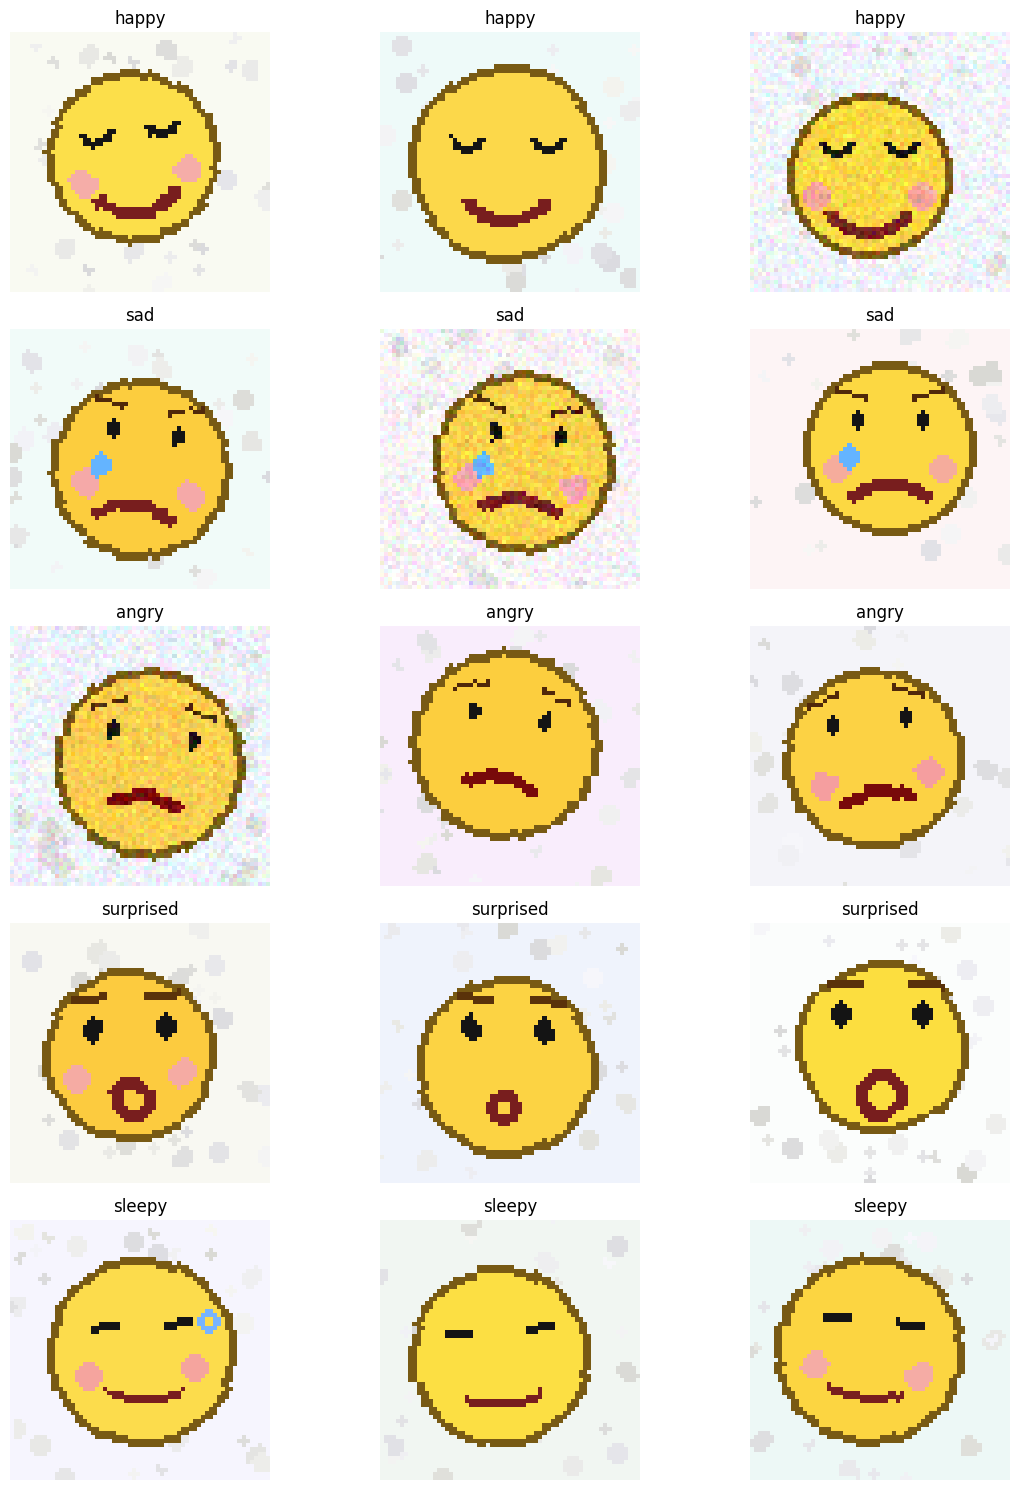

In [6]:
def show_samples_per_class(class_names, samples_per_class=3, hard_mode=False):
    """
    Display sample images from each class
    """
    fig, axes = plt.subplots(len(class_names), samples_per_class, figsize=(12, 3 * len(class_names)))
    
    for i, class_name in enumerate(class_names):
        for j in range(samples_per_class):
            seed = i * 100 + j * 10
            img = draw_emoji(class_name, img_size=IMG_SIZE, seed=seed, hard_mode=hard_mode)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{class_name}")
            axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

show_samples_per_class(CLASS_NAMES, samples_per_class=3)

,split,label_name,label_idx,seed,hard_mode
0,train,sleepy,4,40103,False
1,train,sad,1,10097,False
2,train,sad,1,10086,False
3,train,sad,1,10249,False
4,train,sad,1,10297,False


,split,label_name,count
0,test,angry,100
1,test,happy,100
2,test,sad,100
3,test,sleepy,100
4,test,surprised,100
5,train,angry,300
6,train,happy,300
7,train,sad,300
8,train,sleepy,300
9,train,surprised,300


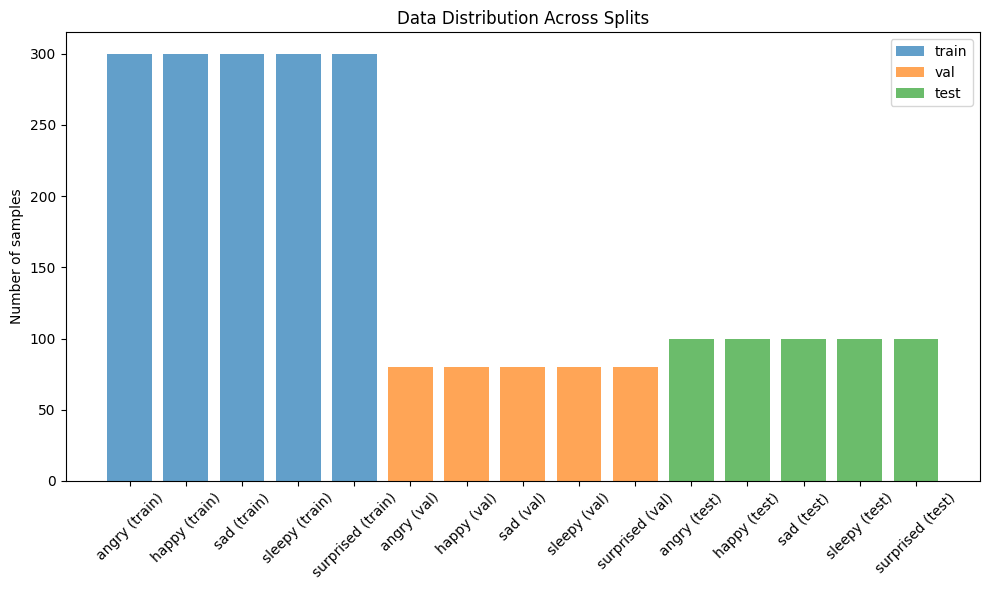

In [7]:
SPLIT_COUNTS = {
    "train": 300,
    "val": 80,
    "test": 100,
}

def build_records(split_name, class_names, counts_per_class, hard_mode=False, seed_offset=0):
    records = []
    label_to_idx = {name: i for i, name in enumerate(class_names)}
    for class_name in class_names:
        label_idx = label_to_idx[class_name]
        for i in range(counts_per_class):
            records.append({
                "split": split_name,
                "label_name": class_name,
                "label_idx": label_idx,
                "seed": seed_offset + 10_000 * label_idx + i,
                "hard_mode": hard_mode,
            })
    random.Random(SEED + seed_offset).shuffle(records)
    return records

train_records = build_records("train", CLASS_NAMES, SPLIT_COUNTS["train"], hard_mode=False, seed_offset=0)
val_records = build_records("val", CLASS_NAMES, SPLIT_COUNTS["val"], hard_mode=False, seed_offset=1000)
test_records = build_records("test", CLASS_NAMES, SPLIT_COUNTS["test"], hard_mode=False, seed_offset=2000)

all_records = pd.DataFrame(train_records + val_records + test_records)
display(all_records.head())

count_df = all_records.groupby(["split", "label_name"]).size().reset_index(name="count")
display(count_df)

plt.figure(figsize=(10, 6))
for split in ["train", "val", "test"]:
    split_data = count_df[count_df["split"] == split]
    plt.bar([f"{c} ({split})" for c in split_data["label_name"]], split_data["count"], alpha=0.7, label=split)
plt.xticks(rotation=45)
plt.ylabel("Number of samples")
plt.title("Data Distribution Across Splits")
plt.legend()
plt.tight_layout()
plt.show()

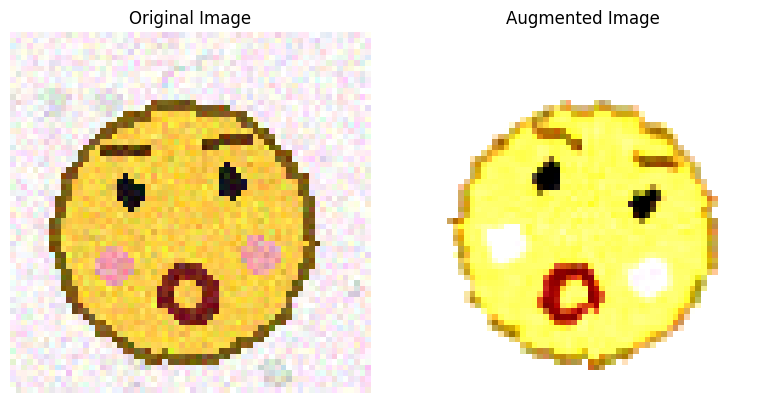

In [11]:
class Compose:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img):
        for t in self.transforms:
            img = t(img)
        return img

class Resize:
    def __init__(self, size):
        if isinstance(size, int):
            size = (size, size)
        self.size = size

    def __call__(self, img):
        return img.resize(self.size, Image.Resampling.BILINEAR)

class RandomHorizontalFlip:
    def __init__(self, p=0.5):
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            return ImageOps.mirror(img)
        return img

class RandomRotation:
    def __init__(self, degrees):
        self.degrees = degrees

    def __call__(self, img):
        angle = random.uniform(-self.degrees, self.degrees)
        return img.rotate(angle, fillcolor=(245, 245, 250))

class RandomResizedCrop:
    def __init__(self, size, scale=(0.85, 1.0)):
        self.size = (size, size) if isinstance(size, int) else size
        self.scale = scale

    def __call__(self, img):
        scale = random.uniform(self.scale[0], self.scale[1])
        new_size = int(IMG_SIZE * scale)
        img = img.resize((new_size, new_size), Image.Resampling.BILINEAR)
        
        if new_size > self.size[0]:
            x = random.randint(0, new_size - self.size[0])
            y = random.randint(0, new_size - self.size[1])
            img = img.crop((x, y, x + self.size[0], y + self.size[1]))
        else:
            img = img.resize(self.size, Image.Resampling.BILINEAR)
        return img

class ColorJitter:
    def __init__(self, brightness=0.0, contrast=0.0, saturation=0.0):
        self.brightness = brightness
        self.contrast = contrast
        self.saturation = saturation

    def __call__(self, img):
        if self.brightness > 0:
            factor = 1 + random.uniform(-self.brightness, self.brightness)
            img = ImageEnhance.Brightness(img).enhance(factor)
        if self.contrast > 0:
            factor = 1 + random.uniform(-self.contrast, self.contrast)
            img = ImageEnhance.Contrast(img).enhance(factor)
        if self.saturation > 0:
            factor = 1 + random.uniform(-self.saturation, self.saturation)
            img = ImageEnhance.Color(img).enhance(factor)
        return img

class ToTensorNormalize:
    def __init__(self, mean, std):
        self.mean = np.array(mean, dtype=np.float32).reshape(3, 1, 1)
        self.std = np.array(std, dtype=np.float32).reshape(3, 1, 1)

    def __call__(self, img):
        img = np.array(img, dtype=np.float32).transpose(2, 0, 1) / 255.0
        img = (img - self.mean) / self.std
        return torch.from_numpy(img).float()

train_transform = Compose([
    RandomRotation(degrees=15),
    RandomHorizontalFlip(p=0.5),
    RandomResizedCrop(size=IMG_SIZE, scale=(0.85, 1.0)),
    ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    ToTensorNormalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = Compose([
    Resize(IMG_SIZE),
    ToTensorNormalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def denormalize(t):
    t = t.clone().cpu()
    for c in range(3):
        t[c] = t[c] * 0.5 + 0.5
    return t.clamp(0, 1)

sample_img = draw_emoji("surprised", img_size=IMG_SIZE, seed=1234)
augmented = train_transform(sample_img)


fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(sample_img)
axes[0].set_title("Original Image")
axes[0].axis("off")

augmented_img = denormalize(augmented)
axes[1].imshow(np.transpose(augmented_img.numpy(), (1, 2, 0)))
axes[1].set_title("Augmented Image")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [12]:
class EmojiMoodDataset(Dataset):
    def __init__(self, records, transform=None):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = draw_emoji(
            rec["label_name"],
            img_size=IMG_SIZE,
            seed=rec["seed"],
            hard_mode=rec["hard_mode"],
        )
        if self.transform is not None:
            img = self.transform(img)
        label = rec["label_idx"]
        return img, label

train_dataset = EmojiMoodDataset(train_records, transform=train_transform)
val_dataset = EmojiMoodDataset(val_records, transform=eval_transform)
test_dataset = EmojiMoodDataset(test_records, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

images, labels = next(iter(train_loader))
print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

Batch image shape: torch.Size([64, 3, 64, 64])
Batch label shape: torch.Size([64])


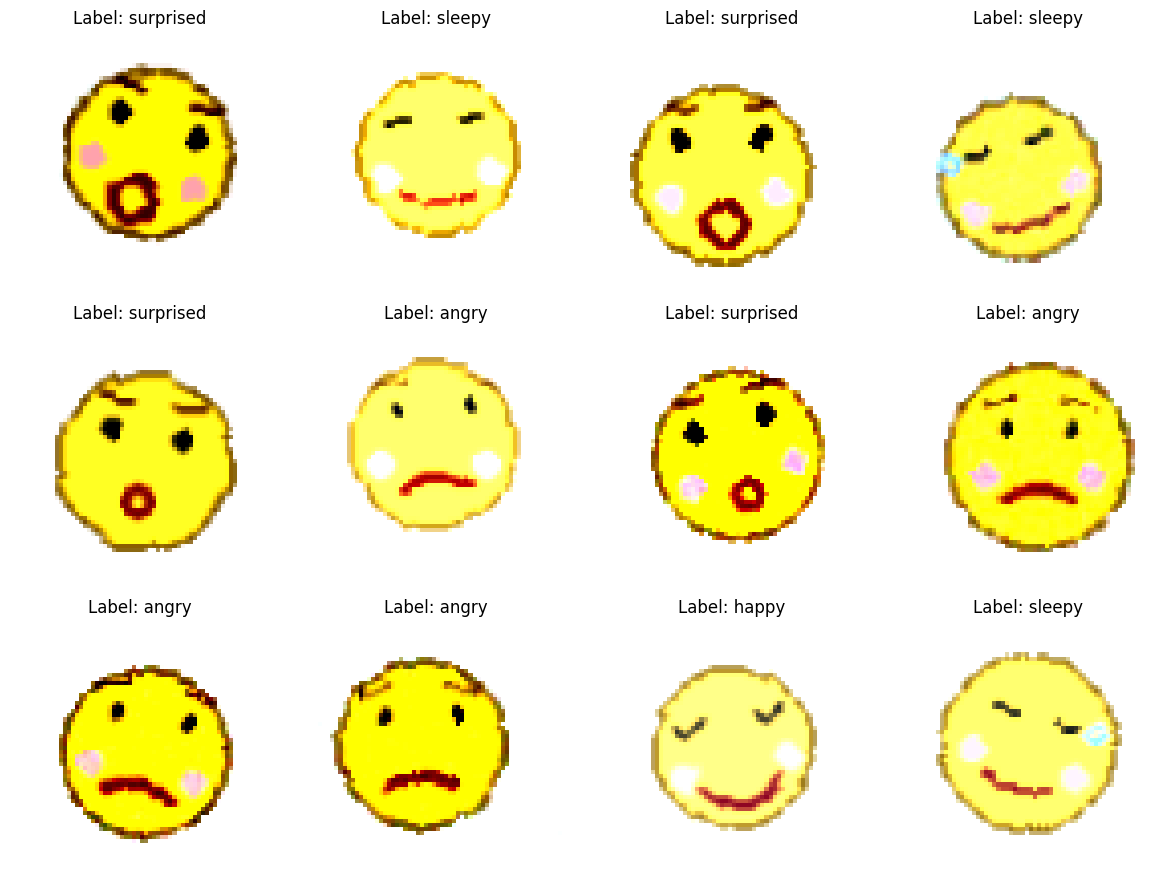

In [13]:
def show_batch(images, labels, class_names, max_items=12):
    n_items = min(max_items, len(images))
    cols = 4
    rows = (n_items + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = np.array(axes).reshape(-1)
    
    for i in range(n_items):
        img = denormalize(images[i])
        axes[i].imshow(np.transpose(img.numpy(), (1, 2, 0)))
        axes[i].set_title(f"Label: {class_names[labels[i]]}")
        axes[i].axis("off")
    
    for i in range(n_items, len(axes)):
        axes[i].axis("off")
    
    plt.tight_layout()
    plt.show()

show_batch(images, labels, CLASS_NAMES)

In [16]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        
        self.feature_size = 128 * (IMG_SIZE // 8) * (IMG_SIZE // 8)
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.feature_size, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.classifier(x)
        return x

baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(baseline_model)
print(f"Trainable params: {count_trainable_params(baseline_model):,}")

with torch.no_grad():
    test_output = baseline_model(images.to(device))
    print(f"Output shape for batch: {test_output.shape}")

BaselineCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.3, inplace=False)
    (7): Linear(in_features=128, out_features=5, bias=True)
  )
)
Trainable params: 2,224,197
Output shape for batch: torch.

In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = total_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc

@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = total_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc

def fit_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=8,
    patience=3
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_state = deepcopy(model.state_dict())
    best_val_loss = float("inf")
    wait = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_one_epoch(model, val_loader, criterion, device)
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)
    return history

In [18]:
baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)

baseline_history = fit_model(
    baseline_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=8,
    patience=3
)

Epoch 01 | train_loss=1.6152 train_acc=0.1947 | val_loss=1.6057 val_acc=0.2600
Epoch 02 | train_loss=1.4763 train_acc=0.3660 | val_loss=0.9286 val_acc=0.6300
Epoch 03 | train_loss=0.7129 train_acc=0.7107 | val_loss=0.2725 val_acc=0.8975
Epoch 04 | train_loss=0.3608 train_acc=0.8327 | val_loss=0.2021 val_acc=0.9100
Epoch 05 | train_loss=0.2456 train_acc=0.8833 | val_loss=0.2173 val_acc=0.8850
Epoch 06 | train_loss=0.2389 train_acc=0.9000 | val_loss=0.0577 val_acc=0.9950
Epoch 07 | train_loss=0.1701 train_acc=0.9367 | val_loss=0.1109 val_acc=0.9625
Epoch 08 | train_loss=0.1553 train_acc=0.9413 | val_loss=0.1015 val_acc=0.9575


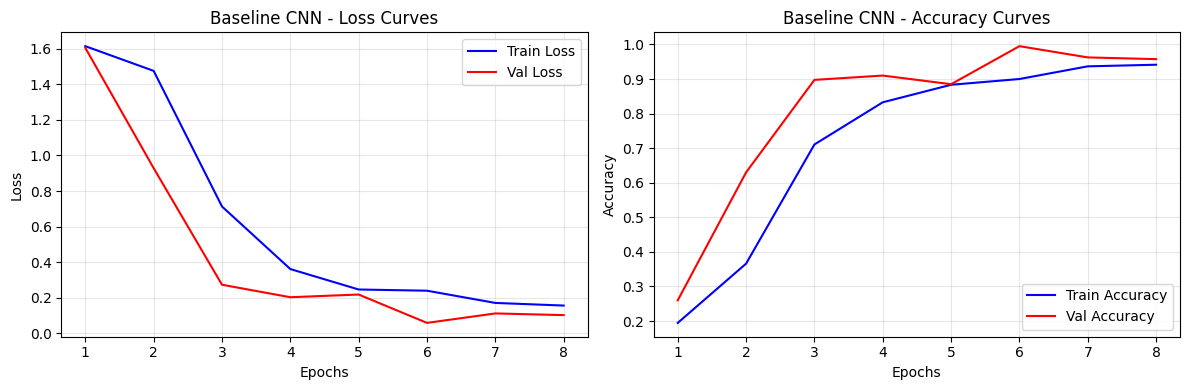

In [19]:
def plot_history(history, title_prefix="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], 'b-', label='Train Loss')
    axes[0].plot(epochs, history["val_loss"], 'r-', label='Val Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title_prefix} - Loss Curves')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, history["train_acc"], 'b-', label='Train Accuracy')
    axes[1].plot(epochs, history["val_acc"], 'r-', label='Val Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title_prefix} - Accuracy Curves')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(baseline_history, title_prefix="Baseline CNN")

Baseline Test Accuracy : 0.9920
Baseline Test Precision: 0.9923
Baseline Test Recall   : 0.9920
Baseline Test F1-score : 0.9920

Classification report:
              precision    recall  f1-score   support

       happy       1.00      1.00      1.00       100
         sad       0.96      1.00      0.98       100
       angry       1.00      0.96      0.98       100
   surprised       1.00      1.00      1.00       100
      sleepy       1.00      1.00      1.00       100

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500



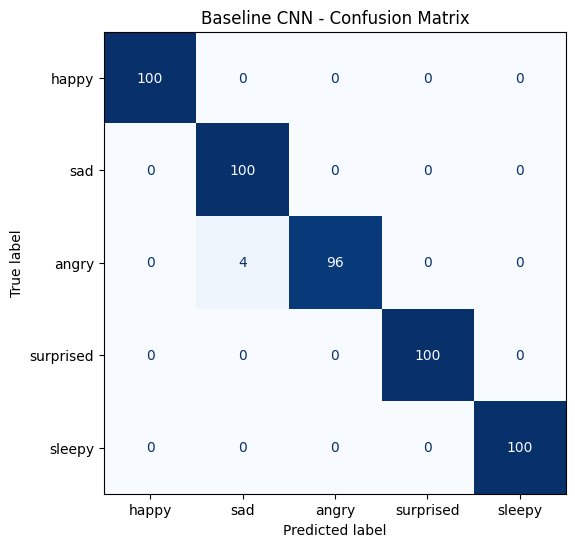

In [20]:
@torch.no_grad()
def predict_loader(model, loader, device):
    model.eval()
    all_probs, all_preds, all_targets = [], [], []

    for images, targets in loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_targets.append(targets)

    all_probs = torch.cat(all_probs).numpy()
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    return all_probs, all_preds, all_targets

# TODO
baseline_probs, baseline_preds, test_targets = predict_loader(baseline_model, test_loader, device)

baseline_acc = accuracy_score(test_targets, baseline_preds)
baseline_prec, baseline_rec, baseline_f1, _ = precision_recall_fscore_support(
    test_targets, baseline_preds, average='macro'
)

print(f"Baseline Test Accuracy : {baseline_acc:.4f}")
print(f"Baseline Test Precision: {baseline_prec:.4f}")
print(f"Baseline Test Recall   : {baseline_rec:.4f}")
print(f"Baseline Test F1-score : {baseline_f1:.4f}")

print("\nClassification report:")
print(classification_report(test_targets, baseline_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(test_targets, baseline_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Baseline CNN - Confusion Matrix")
plt.show()

Number of mistakes: 1 / 200


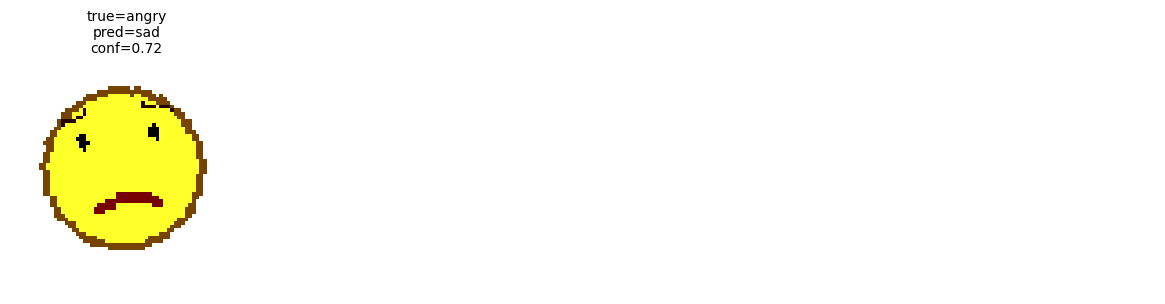

In [22]:
@torch.no_grad()
def collect_predictions_with_images(model, dataset, device, max_items=None):
    model.eval()
    items = []
    total = len(dataset) if max_items is None else min(len(dataset), max_items)

    for idx in range(total):
        image, label = dataset[idx]
        x = image.unsqueeze(0).to(device)
        output = model(x)
        prob = torch.softmax(output, dim=1)
        pred = output.argmax(dim=1).item()

        items.append({
            "image": image,
            "label": label,
            "pred": pred,
            "confidence": float(prob[0][pred].item()),
        })
    return items

test_items = collect_predictions_with_images(baseline_model, test_dataset, device, max_items=200)
mistakes = [item for item in test_items if item["label"] != item["pred"]]
mistakes = sorted(mistakes, key=lambda x: x["confidence"], reverse=True)

print(f"Number of mistakes: {len(mistakes)} / {len(test_items)}")

n_show = min(12, len(mistakes))
if n_show > 0:
    cols = 4
    rows = math.ceil(n_show / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = np.array(axes).reshape(rows, cols)

    for ax in axes.ravel():
        ax.axis("off")

    for i in range(n_show):
        item = mistakes[i]
        img = np.transpose(denormalize(item["image"]).numpy(), (1, 2, 0))
        ax = axes.ravel()[i]
        ax.imshow(img)
        ax.set_title(
            f"true={CLASS_NAMES[item['label']]}\npred={CLASS_NAMES[item['pred']]}\nconf={item['confidence']:.2f}",
            fontsize=10
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Great! No mistakes found in the displayed set.")

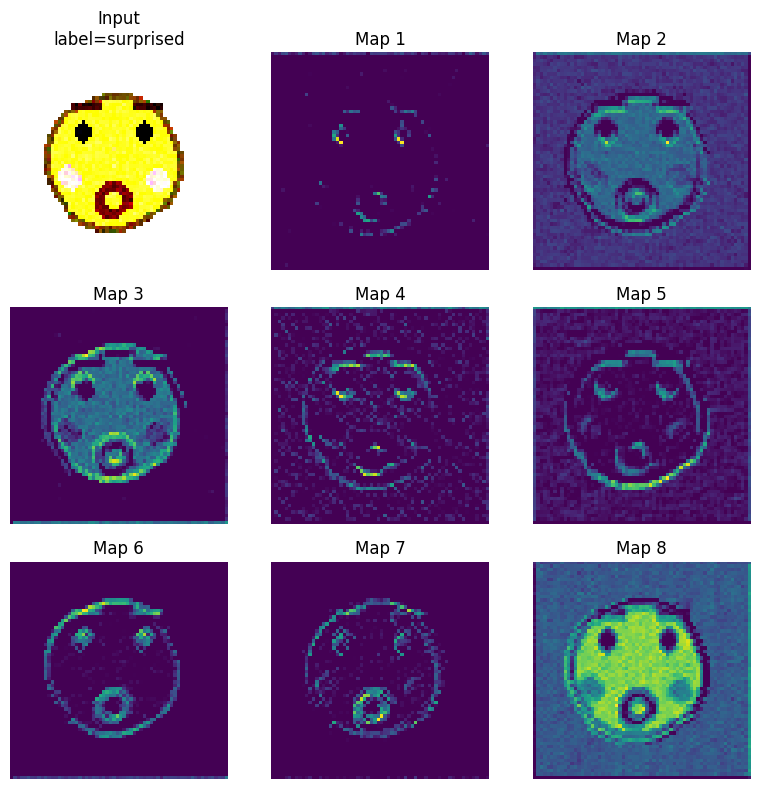

In [23]:
@torch.no_grad()
def show_feature_maps(model, dataset, sample_idx=0, n_maps=8):
    model.eval()
    image, label = dataset[sample_idx]
    x = image.unsqueeze(0).to(device)

    first_block = model.conv_layers[0:2]
    fmap = first_block(x).squeeze(0).cpu()

    fig, axes = plt.subplots(3, 3, figsize=(8, 8))
    axes = axes.ravel()

    axes[0].imshow(np.transpose(denormalize(image).numpy(), (1, 2, 0)))
    axes[0].set_title(f"Input\nlabel={CLASS_NAMES[label]}")
    axes[0].axis("off")

    for i in range(1, min(n_maps + 1, 9)):
        axes[i].imshow(fmap[i - 1], cmap="viridis")
        axes[i].set_title(f"Map {i}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

show_feature_maps(baseline_model, test_dataset, sample_idx=3, n_maps=8)

In [24]:
class BetterCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.classifier(x)
        return x

better_model = BetterCNN(num_classes=NUM_CLASSES).to(device)
print(better_model)
print(f"Trainable params: {count_trainable_params(better_model):,}")

BetterCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), pa

Epoch 01 | train_loss=0.7636 train_acc=0.7033 | val_loss=1.2148 val_acc=0.4525
Epoch 02 | train_loss=0.2066 train_acc=0.9273 | val_loss=0.3199 val_acc=0.9025
Epoch 03 | train_loss=0.0866 train_acc=0.9753 | val_loss=2.2841 val_acc=0.3350
Epoch 04 | train_loss=0.0663 train_acc=0.9807 | val_loss=0.2770 val_acc=0.8600
Epoch 05 | train_loss=0.0487 train_acc=0.9873 | val_loss=0.1352 val_acc=0.9350
Epoch 06 | train_loss=0.0359 train_acc=0.9907 | val_loss=0.0056 val_acc=1.0000
Epoch 07 | train_loss=0.0172 train_acc=0.9980 | val_loss=0.0055 val_acc=1.0000
Epoch 08 | train_loss=0.0217 train_acc=0.9947 | val_loss=0.0221 val_acc=0.9925
Epoch 09 | train_loss=0.0206 train_acc=0.9940 | val_loss=0.0117 val_acc=1.0000
Epoch 10 | train_loss=0.0218 train_acc=0.9947 | val_loss=0.1654 val_acc=0.9375


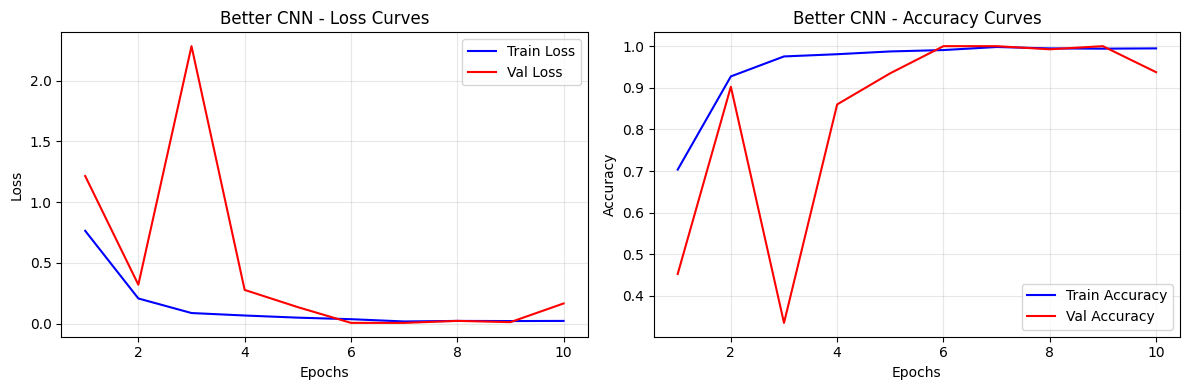

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(better_model.parameters(), lr=0.001, weight_decay=1e-4)

better_history = fit_model(
    better_model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    patience=4,
)

plot_history(better_history, title_prefix="Better CNN")

,model,accuracy,precision_macro,recall_macro,f1_macro,params
0,BaselineCNN,0.992,0.992308,0.992,0.991997,2224197
1,BetterCNN,1.000,1.000000,1.000,1.000000,3379013


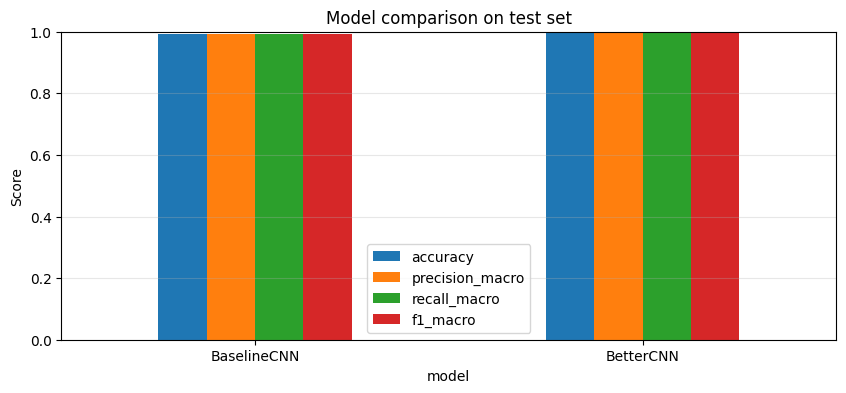

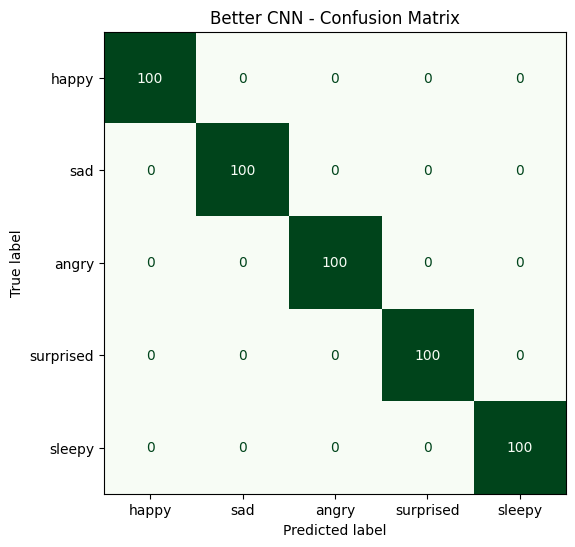

In [26]:
better_probs, better_preds, _ = predict_loader(better_model, test_loader, device)

better_acc = accuracy_score(test_targets, better_preds)
better_prec, better_rec, better_f1, _ = precision_recall_fscore_support(
    test_targets, better_preds, average='macro'
)

comparison_df = pd.DataFrame([
    {
        "model": "BaselineCNN",
        "accuracy": baseline_acc,
        "precision_macro": baseline_prec,
        "recall_macro": baseline_rec,
        "f1_macro": baseline_f1,
        "params": count_trainable_params(baseline_model),
    },
    {
        "model": "BetterCNN",
        "accuracy": better_acc,
        "precision_macro": better_prec,
        "recall_macro": better_rec,
        "f1_macro": better_f1,
        "params": count_trainable_params(better_model),
    },
])

display(comparison_df)

comparison_df.set_index("model")[["accuracy", "precision_macro", "recall_macro", "f1_macro"]].plot(
    kind="bar", figsize=(10, 4)
)
plt.ylim(0, 1.0)
plt.ylabel("Score")
plt.title("Model comparison on test set")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.show()

cm_better = confusion_matrix(test_targets, better_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_better, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Greens", values_format="d", colorbar=False)
plt.title("Better CNN - Confusion Matrix")
plt.show()

1. Yes. Augmentation helped because it made the model see different versions of the same image and this taught the model to be more flexible and not just memorize the training images so it worked better on new images.

2. Sad and angry. Both have similar mouth shapes and eyes that look serious or tired.

3. BN helped the most because it made training faster and more stable and also AdaptiveAvgPool2d helped a lot because it reduced overfitting and deeper layers and more dropout also helped but less than BN.

4. No. It may just memorizes the training data and fails on new images.

5. Add two more emotions like "cool" and "confused" or use fewer training images

In [27]:
# BONUS 1: Harder Test Set with Stronger Occlusion

def draw_emoji_hard(label, img_size=64, seed=0):
    """Same as draw_emoji but with more extreme augmentations"""
    rng = random.Random(seed)

    img = draw_emoji(label, img_size, seed, hard_mode=True)
    
    if rng.random() < 0.6:
        # Add black bar occlusion
        y_start = rng.randint(20, 44)
        draw = ImageDraw.Draw(img)
        draw.rectangle((0, y_start, img_size, y_start + rng.randint(8, 15)), 
                       fill=(100, 100, 100))
    
    if rng.random() < 0.4:
        # Add scratch like occlusion
        draw = ImageDraw.Draw(img)
        for _ in range(rng.randint(2, 5)):
            x1 = rng.randint(10, 54)
            y1 = rng.randint(10, 54)
            draw.line((x1, y1, x1 + rng.randint(-10, 10), y1 + rng.randint(-10, 10)), 
                     fill=(80, 80, 80), width=3)
    
    return img

hard_test_records = build_records("hard_test", CLASS_NAMES, 50, hard_mode=True, seed_offset=5000)
hard_test_dataset = EmojiMoodDataset(hard_test_records, transform=eval_transform)
hard_test_loader = DataLoader(hard_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

hard_probs, hard_preds, hard_targets = predict_loader(better_model, hard_test_loader, device)
hard_acc = accuracy_score(hard_targets, hard_preds)
print(f"BetterCNN on Hard Test Set Accuracy: {hard_acc:.4f}")
print(f"Drop from standard test: {(better_acc - hard_acc)*100:.2f}%")

BetterCNN on Hard Test Set Accuracy: 0.9760
Drop from standard test: 2.40%


In [28]:
# BONUS 2: Compare Adam vs RMSprop Optimizers

def compare_optimizers(model_class, train_loader, val_loader, device, epochs=8):
    """Compare Adam and RMSprop optimizers"""
    results = {}
    
    print("\nTraining with Adam:")
    model_adam = model_class(num_classes=NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer_adam = torch.optim.Adam(model_adam.parameters(), lr=0.001)
    history_adam = fit_model(model_adam, train_loader, val_loader, criterion, optimizer_adam, device, epochs=epochs, patience=3)
    _, preds_adam, _ = predict_loader(model_adam, test_loader, device)
    acc_adam = accuracy_score(test_targets, preds_adam)
    
    print("\nTraining with RMSprop:")
    model_rms = model_class(num_classes=NUM_CLASSES).to(device)
    optimizer_rms = torch.optim.RMSprop(model_rms.parameters(), lr=0.001, alpha=0.99)
    history_rms = fit_model(model_rms, train_loader, val_loader, criterion, optimizer_rms, device, epochs=epochs, patience=3)
    _, preds_rms, _ = predict_loader(model_rms, test_loader, device)
    acc_rms = accuracy_score(test_targets, preds_rms)
    
    results = {
        'Adam': {'accuracy': acc_adam, 'history': history_adam},
        'RMSprop': {'accuracy': acc_rms, 'history': history_rms}
    }
    
    return results

optimizer_comparison = compare_optimizers(BetterCNN, train_loader, val_loader, device, epochs=5)
print(f"\nOptimizer Comparison:")
for opt, res in optimizer_comparison.items():
    print(f"{opt}: {res['accuracy']:.4f}")


Training with Adam:
Epoch 01 | train_loss=0.6362 train_acc=0.7687 | val_loss=0.5436 val_acc=0.7600
Epoch 02 | train_loss=0.1798 train_acc=0.9460 | val_loss=0.7521 val_acc=0.7650
Epoch 03 | train_loss=0.0640 train_acc=0.9860 | val_loss=0.5299 val_acc=0.8375
Epoch 04 | train_loss=0.0652 train_acc=0.9853 | val_loss=0.1003 val_acc=0.9750
Epoch 05 | train_loss=0.0358 train_acc=0.9920 | val_loss=0.0249 val_acc=0.9975

Training with RMSprop:
Epoch 01 | train_loss=0.8414 train_acc=0.6287 | val_loss=0.4054 val_acc=0.8275
Epoch 02 | train_loss=0.2878 train_acc=0.8653 | val_loss=0.2688 val_acc=0.8675
Epoch 03 | train_loss=0.1996 train_acc=0.9240 | val_loss=0.1277 val_acc=0.9650
Epoch 04 | train_loss=0.1274 train_acc=0.9580 | val_loss=1.2435 val_acc=0.6375
Epoch 05 | train_loss=0.1343 train_acc=0.9527 | val_loss=0.0982 val_acc=0.9625

Optimizer Comparison:
Adam: 1.0000
RMSprop: 0.9420


In [29]:
# BONUS 3: Label Smoothing Loss

class LabelSmoothingCrossEntropy(nn.Module):
    """Cross Entropy Loss with Label Smoothing"""
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
        
    def forward(self, pred, target):
        n_classes = pred.size(1)
        with torch.no_grad():
            true_dist = torch.zeros_like(pred)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1 - self.smoothing)
        return torch.mean(torch.sum(-true_dist * torch.log_softmax(pred, dim=1), dim=1))

model_smooth = BetterCNN(num_classes=NUM_CLASSES).to(device)
criterion_smooth = LabelSmoothingCrossEntropy(smoothing=0.1)
optimizer_smooth = torch.optim.Adam(model_smooth.parameters(), lr=0.001)

history_smooth = fit_model(model_smooth, train_loader, val_loader, criterion_smooth, optimizer_smooth, device, epochs=8, patience=3)

_, preds_smooth, _ = predict_loader(model_smooth, test_loader, device)
acc_smooth = accuracy_score(test_targets, preds_smooth)
print(f"Label Smoothing Test Accuracy: {acc_smooth:.4f}")
print(f"Improvement over baseline: {(acc_smooth - baseline_acc)*100:.2f}%")

Epoch 01 | train_loss=0.9426 train_acc=0.7307 | val_loss=1.3223 val_acc=0.4750
Epoch 02 | train_loss=0.5973 train_acc=0.9500 | val_loss=1.3246 val_acc=0.6050
Epoch 03 | train_loss=0.5420 train_acc=0.9833 | val_loss=0.5950 val_acc=0.9425
Epoch 04 | train_loss=0.5398 train_acc=0.9800 | val_loss=0.6822 val_acc=0.8850
Epoch 05 | train_loss=0.5096 train_acc=0.9967 | val_loss=0.5025 val_acc=1.0000
Epoch 06 | train_loss=0.4966 train_acc=0.9987 | val_loss=0.4742 val_acc=1.0000
Epoch 07 | train_loss=0.4935 train_acc=0.9987 | val_loss=0.5012 val_acc=0.9950
Epoch 08 | train_loss=0.4912 train_acc=1.0000 | val_loss=0.5039 val_acc=0.9975
Label Smoothing Test Accuracy: 1.0000
Improvement over baseline: 0.80%


f:\hallucinations project\venv\Lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


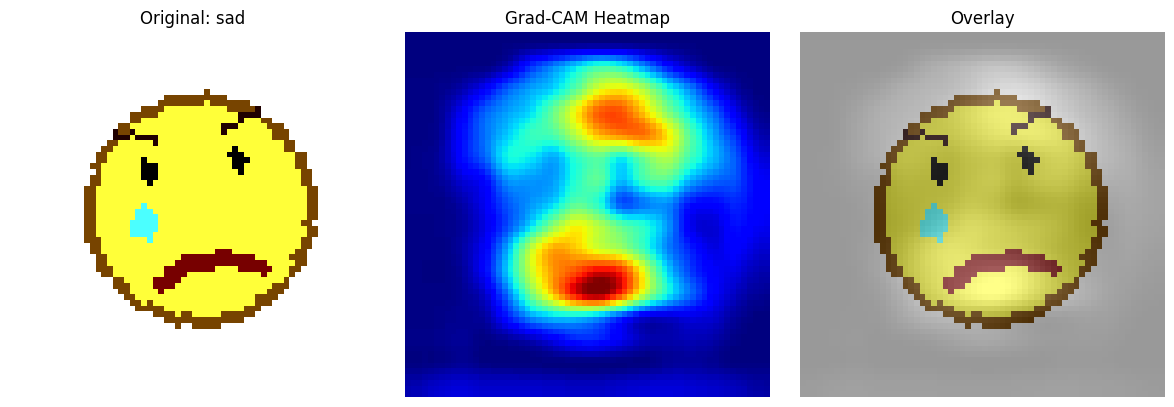

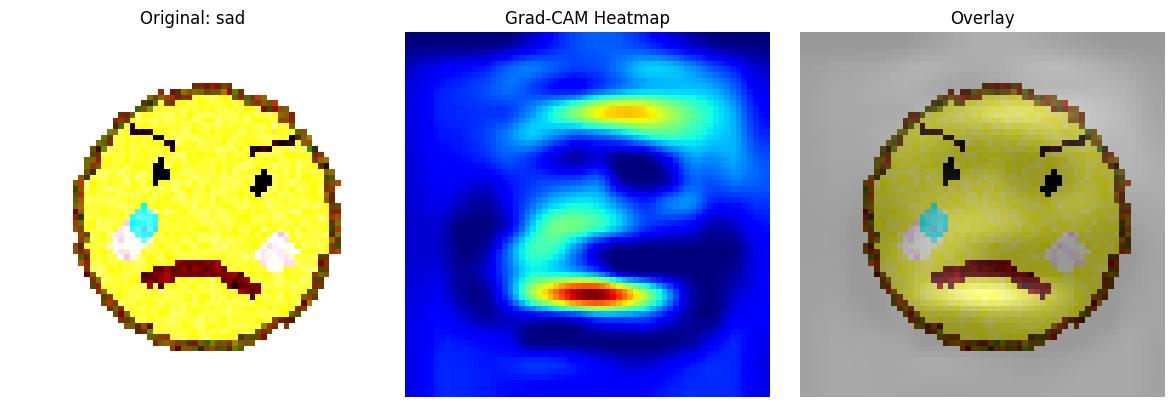

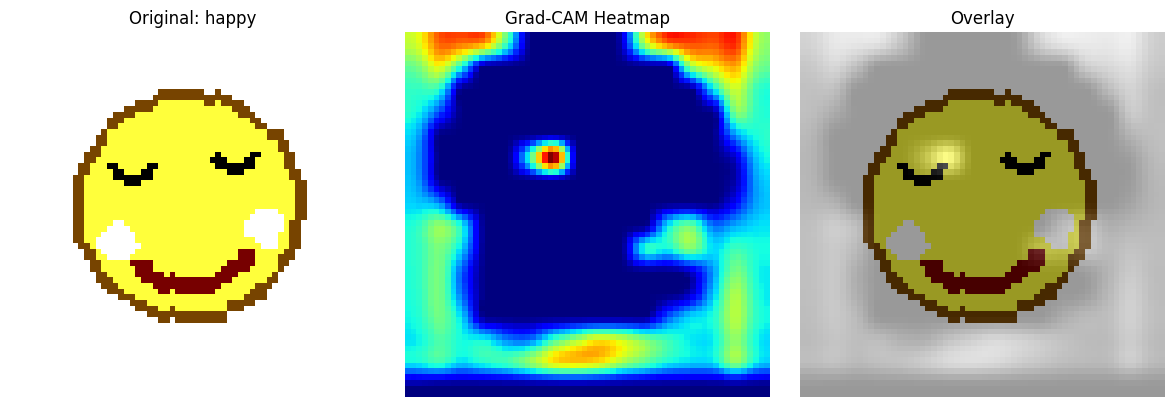

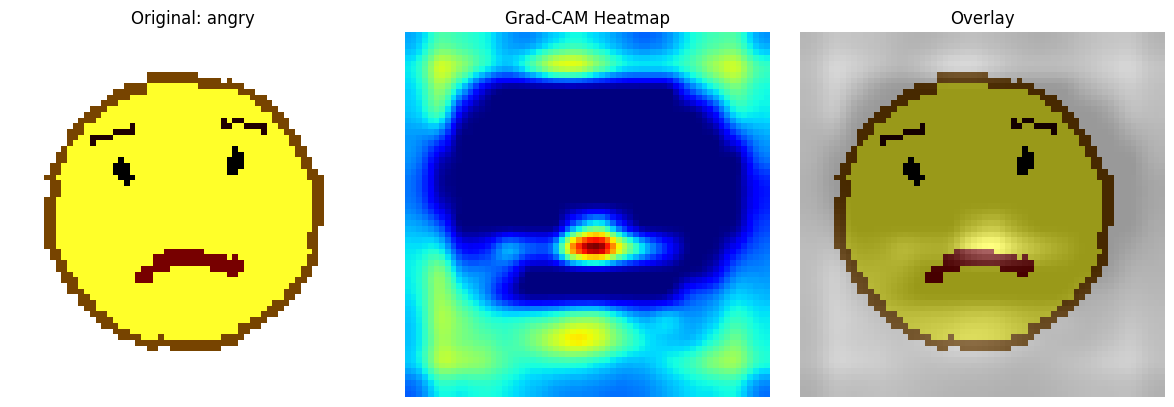

In [30]:
# BONUS 4: Grad-CAM Implementation

class GradCAM:
    """Gradient-weighted Class Activation Mapping"""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_heatmap(self, input_image, target_class=None):
        self.model.eval()
        input_image = input_image.unsqueeze(0).to(device)
        input_image.requires_grad = True
        
        output = self.model(input_image)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        
        self.model.zero_grad()
        
        output[0, target_class].backward()
        
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        for i in range(pooled_gradients.size(0)):
            self.activations[:, i, :, :] *= pooled_gradients[i]
        
        heatmap = torch.mean(self.activations, dim=1).squeeze().cpu()
        heatmap = torch.relu(heatmap)
        heatmap = heatmap / (torch.max(heatmap) + 1e-8)
        
        return heatmap.numpy()

def visualize_gradcam(model, dataset, sample_idx=0):
    """Visualize Grad-CAM heatmap on sample image"""
    model.eval()
    image, label = dataset[sample_idx]
    
    target_layer = model.conv_layers[-4]

    gradcam = GradCAM(model, target_layer)
    heatmap = gradcam.generate_heatmap(image.to(device))
    
    from PIL import Image as PILImage
    heatmap_resized = np.array(PILImage.fromarray((heatmap * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE))) / 255.0
    
    img_disp = denormalize(image).numpy().transpose(1, 2, 0)
    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_disp)
    axes[0].set_title(f"Original: {CLASS_NAMES[label]}")
    axes[0].axis('off')
    
    axes[1].imshow(heatmap_resized, cmap='jet')
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis('off')
    
    overlay = img_disp * 0.6 + np.stack([heatmap_resized, heatmap_resized, heatmap_resized], axis=2) * 0.4
    axes[2].imshow(np.clip(overlay, 0, 1))
    axes[2].set_title("Overlay")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

for idx in [0, 5, 10, 15]:
    visualize_gradcam(better_model, test_dataset, sample_idx=idx)